# Git churn and scattering for the nine-developer cohort

This notebook analyzes every available monthly snapshot from **2025-11-01 through 2026-04-30** for all nine handles in `developers.json`. September and October are excluded because too few projects are represented in those months to support cohort-level conclusions. The analysis joins the monthly commit records to `data/commits/{sha}.json`, which contains GitHub's per-file additions and deletions.

Definitions used here:

- **additions**: sum of `file.additions` in a commit.
- **deletions**: sum of `file.deletions` in a commit.
- **churn**: additions + deletions (gross changed lines).
- **net growth**: additions - deletions.
- **file scattering**: number of changed files in a commit (`len(files)`).
- **file touches**: sum of per-commit file scattering; changing one path in ten commits counts as ten touches.

Percentiles describe the **per-commit distribution**. Totals are reported separately because a percentile of an already aggregated scalar is not meaningful. The cache is based on GitHub API responses: empty file lists and responses at the unpaginated 300-file threshold are surfaced in the coverage audit. GitHub supports pagination to 3,000 files, but the collector stored only the first response.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

START_DATE = pd.Timestamp("2025-11-01")
END_DATE = pd.Timestamp("2026-04-30")

# A SHA can appear more than once through forks or mirrors. Keep one authored
# change per developer by default. Set False to count every GitHub appearance.
DEDUPLICATE_BY_SHA = True

# GitHub represents a merge commit as a diff against a parent. Keep these in
# the headline result, but show a merge-excluded sensitivity check at the end.
INCLUDE_MERGES = True

FILE_LIST_LIMIT = 300

## Locate and load the dataset

The root finder makes the notebook work whether Jupyter starts in the repository root or in this directory. Snapshot selection uses JSON metadata and date keys rather than relying on filename shape; this includes both Dicklesworthstone April shards.

In [2]:
def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "developers.json").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate developers.json and data/")

ROOT = find_repository_root()
DATA_DIR = ROOT / "data"
CACHE_DIR = DATA_DIR / "commits"

registry = json.loads((ROOT / "developers.json").read_text())
developers = [entry["handle"] for entry in registry]
developer_set = set(developers)

snapshot_rows = []
raw_records = []

for path in sorted(DATA_DIR.glob("*.json")):
    snapshot = json.loads(path.read_text())
    developer = snapshot.get("developer")
    if developer not in developer_set or not isinstance(snapshot.get("days"), dict):
        continue

    selected_days = {
        day: values
        for day, values in snapshot["days"].items()
        if START_DATE <= pd.Timestamp(day) <= END_DATE
    }
    if not selected_days:
        continue

    embedded = sum(len(values.get("commits", [])) for values in selected_days.values())
    reported = sum(int(values.get("total_count", 0)) for values in selected_days.values())
    capped_days = sum(
        int(values.get("total_count", 0)) > len(values.get("commits", []))
        for values in selected_days.values()
    )
    snapshot_rows.append({
        "developer": developer,
        "snapshot": path.name,
        "reported_commits": reported,
        "embedded_records": embedded,
        "capped_days": capped_days,
    })

    for day, values in selected_days.items():
        for commit in values.get("commits", []):
            raw_records.append({
                "developer": developer,
                "day": day,
                "snapshot": path.name,
                "commit": commit,
            })

snapshot_audit = pd.DataFrame(snapshot_rows)
print(f"Repository: {ROOT}")
print(f"Developers ({len(developers)}): {', '.join(developers)}")
print(f"Snapshots selected: {len(snapshot_audit):,}")
print(f"Embedded commit records: {len(raw_records):,}")

Repository: /home/dig/repositories/what-are-they-doing
Developers (9): steipete, Dicklesworthstone, ruvnet, obra, philipp-spiess, mavam, teamchong, clubanderson, steveyegge
Snapshots selected: 55
Embedded commit records: 144,349


In [3]:
def repository_from_commit(commit: dict) -> str | None:
    repository = commit.get("repository") or {}
    if repository.get("full_name"):
        return repository["full_name"]
    url = commit.get("url", "")
    match = re.search(r"/repos/([^/]+/[^/]+)/commits/", url)
    if match:
        return match.group(1)
    html_url = commit.get("html_url", "")
    match = re.search(r"github\.com/([^/]+/[^/]+)/commit/", html_url)
    return match.group(1) if match else None

seen = set()
selected_records = []
duplicate_records = 0

for record in raw_records:
    sha = record["commit"].get("sha")
    key = (record["developer"], sha) if DEDUPLICATE_BY_SHA else (len(selected_records),)
    if key in seen:
        duplicate_records += 1
        continue
    seen.add(key)
    selected_records.append(record)

print(f"Records after deduplication: {len(selected_records):,}")
print(f"Duplicate developer/SHA appearances removed: {duplicate_records:,}")

Records after deduplication: 143,996
Duplicate developer/SHA appearances removed: 353


## Join commit records to file-level details

Legacy cache files containing a bare list and current `{message, files}` cache files are both supported. Missing caches are retained in the audit but excluded from numerical distributions rather than silently interpreted as zero-change commits.

In [4]:
rows = []
touch_rows = []
for record in selected_records:
    developer = record["developer"]
    commit = record["commit"]
    sha = commit.get("sha", "")
    repository = repository_from_commit(commit)
    cache_path = CACHE_DIR / f"{sha}.json"
    is_merge = len(commit.get("parents", [])) > 1

    if cache_path.is_file():
        detail = json.loads(cache_path.read_text())
        files = detail if isinstance(detail, list) else detail.get("files", [])
        cache_present = True
        additions = sum(int(file.get("additions", 0) or 0) for file in files)
        deletions = sum(int(file.get("deletions", 0) or 0) for file in files)
        files_touched = len(files)
        # Breadth: the distinct top-level directories a commit reaches into.
        names = [file.get("filename", "") for file in files]
        modules = len({name.split("/")[0] if "/" in name else "<root>" for name in names})
        for file in files:
            touch_rows.append({
                "developer": developer,
                "sha": sha,
                "repository": repository,
                "day": pd.Timestamp(record["day"]),
                "filename": file.get("filename", ""),
                "churn": int(file.get("additions", 0) or 0) + int(file.get("deletions", 0) or 0),
            })
    else:
        cache_present = False
        additions = deletions = files_touched = modules = np.nan

    rows.append({
        "developer": developer,
        "day": pd.Timestamp(record["day"]),
        "month": record["day"][:7],
        "sha": sha,
        "repository": repository,
        "is_merge": is_merge,
        "cache_present": cache_present,
        "empty_file_list": cache_present and files_touched == 0,
        "at_file_list_limit": cache_present and files_touched >= FILE_LIST_LIMIT,
        "additions": additions,
        "deletions": deletions,
        "churn": additions + deletions,
        "net_growth": additions - deletions,
        "files_touched": files_touched,
        "modules": modules,
    })

commits = pd.DataFrame(rows)
analysis = commits.loc[commits["cache_present"]].copy()
if not INCLUDE_MERGES:
    analysis = analysis.loc[~analysis["is_merge"]].copy()

for column in ["additions", "deletions", "churn", "net_growth", "files_touched", "modules"]:
    analysis[column] = analysis[column].astype("int64")

# One row per changed file of an analyzed commit, used for the revisit analysis.
file_touches = pd.DataFrame(touch_rows).merge(
    analysis[["developer", "sha"]], on=["developer", "sha"], how="inner"
)

print(f"Commits used in headline statistics: {len(analysis):,}")
print(f"Changed-file records: {len(file_touches):,}")

Commits used in headline statistics: 143,996
Changed-file records: 715,672


## Coverage audit

`reported_commits` comes from each day's `total_count`; `embedded_records` is the number of actual commit objects available locally. Consequently, `unembedded_commits` cannot contribute to churn or scattering. A file count at the configured API limit is a warning that scattering and churn may be lower bounds for that commit.

In [5]:
collection_coverage = (
    snapshot_audit.groupby("developer", sort=False)
    .agg(
        snapshots=("snapshot", "count"),
        reported_commits=("reported_commits", "sum"),
        embedded_records=("embedded_records", "sum"),
        capped_days=("capped_days", "sum"),
    )
    .reindex(developers)
)
collection_coverage["unembedded_commits"] = (
    collection_coverage["reported_commits"] - collection_coverage["embedded_records"]
)

detail_coverage = (
    commits.groupby("developer", sort=False)
    .agg(
        unique_commits=("sha", "size"),
        missing_cache=("cache_present", lambda values: int((~values).sum())),
        empty_file_lists=("empty_file_list", "sum"),
        at_300_file_limit=("at_file_list_limit", "sum"),
        merge_commits=("is_merge", "sum"),
    )
    .reindex(developers)
)

coverage = collection_coverage.join(detail_coverage)
display(coverage.style.format("{:,}"))
display(coverage.sum(numeric_only=True).to_frame("all developers").T.style.format("{:,}"))

,snapshots,reported_commits,embedded_records,capped_days,unembedded_commits,unique_commits,missing_cache,empty_file_lists,at_300_file_limit,merge_commits
developer,,,,,,,,,,
steipete,6,"35,091","35,091",0,0,"35,089",0,144,48,513
Dicklesworthstone,7,"75,076","70,951",20,"4,125","70,843",0,193,79,56
ruvnet,6,"5,981","5,625",4,356,"5,383",0,18,56,283
obra,6,"4,419","4,419",0,0,"4,419",0,2,7,88
philipp-spiess,6,808,808,0,0,808,0,1,0,2
mavam,6,"2,685","2,685",0,0,"2,685",0,2,11,148
teamchong,6,"7,204","7,204",0,0,"7,204",0,5,14,0
clubanderson,6,"8,537","8,537",0,0,"8,536",0,34,8,387
steveyegge,6,"9,029","9,029",0,0,"9,029",0,44,0,"1,390"


,snapshots,reported_commits,embedded_records,capped_days,unembedded_commits,unique_commits,missing_cache,empty_file_lists,at_300_file_limit,merge_commits
all developers,55,"148,830","144,349",24,"4,481","143,996",0,443,223,"2,867"


## All developers aggregated

The first table contains additive totals over all analyzable commits. The second summarizes the per-commit distributions. Churn and file counts are strongly right-skewed, so the median and quartiles are usually more representative of a typical commit than the mean.

In [6]:
PERCENTILES = [0.05, 0.25, 0.50, 0.75, 0.95]
METRICS = ["additions", "deletions", "churn", "files_touched"]

def distribution_table(frame: pd.DataFrame) -> pd.DataFrame:
    records = []
    for metric in METRICS:
        values = frame[metric].dropna()
        quantiles = values.quantile(PERCENTILES)
        records.append({
            "metric": metric,
            "count": len(values),
            "p5": quantiles.loc[0.05],
            "p25": quantiles.loc[0.25],
            "median": quantiles.loc[0.50],
            "mean": values.mean(),
            "p75": quantiles.loc[0.75],
            "p95": quantiles.loc[0.95],
            "max": values.max(),
        })
    return pd.DataFrame(records).set_index("metric")

overall_totals = pd.DataFrame({
    "commits": [len(analysis)],
    "additions": [analysis["additions"].sum()],
    "deletions": [analysis["deletions"].sum()],
    "gross_churn": [analysis["churn"].sum()],
    "net_growth": [analysis["net_growth"].sum()],
    "file_touches": [analysis["files_touched"].sum()],
}, index=["all developers"])

display(overall_totals.style.format("{:,}"))
display(distribution_table(analysis).style.format({
    "count": "{:,.0f}",
    "p5": "{:,.1f}", "p25": "{:,.1f}", "median": "{:,.1f}",
    "mean": "{:,.1f}", "p75": "{:,.1f}", "p95": "{:,.1f}", "max": "{:,.0f}",
}))

,commits,additions,deletions,gross_churn,net_growth,file_touches
all developers,"143,996","75,895,109","21,081,895","96,977,004","54,813,214","715,672"


,count,p5,p25,median,mean,p75,p95,max
metric,,,,,,,,
additions,"143,996",1.0,7.0,49.0,527.1,207.0,"1,269.2","1,700,861"
deletions,"143,996",0.0,1.0,5.0,146.4,25.0,245.0,"1,695,122"
churn,"143,996",2.0,13.0,70.0,673.5,263.0,"1,605.0","1,700,869"
files_touched,"143,996",1.0,1.0,2.0,5.0,4.0,14.0,300


## Results by developer

In [7]:
developer_totals = (
    analysis.groupby("developer", sort=False)
    .agg(
        commits=("sha", "size"),
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        gross_churn=("churn", "sum"),
        net_growth=("net_growth", "sum"),
        file_touches=("files_touched", "sum"),
    )
    .reindex(developers)
)
display(developer_totals.style.format("{:,}"))

,commits,additions,deletions,gross_churn,net_growth,file_touches
developer,,,,,,
steipete,"35,089","6,194,388","3,792,462","9,986,850","2,401,926","193,148"
Dicklesworthstone,"70,843","40,057,929","8,894,347","48,952,276","31,163,582","306,906"
ruvnet,"5,383","17,028,089","2,676,262","19,704,351","14,351,827","64,147"
obra,"4,419","1,389,501","312,015","1,701,516","1,077,486","19,334"
philipp-spiess,808,"168,031","56,793","224,824","111,238","2,943"
mavam,"2,685","561,334","918,472","1,479,806","-357,138","18,987"
teamchong,"7,204","5,974,269","1,970,945","7,945,214","4,003,324","42,139"
clubanderson,"8,536","2,251,879","753,366","3,005,245","1,498,513","38,012"
steveyegge,"9,029","2,269,689","1,707,233","3,976,922","562,456","30,056"


In [8]:
def metric_by_developer(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    grouped = frame.groupby("developer", sort=False)[metric]
    result = grouped.agg(count="size", minimum="min", mean="mean", maximum="max")
    quantiles = grouped.quantile(PERCENTILES).unstack()
    quantiles.columns = ["p5", "p25", "median", "p75", "p95"]
    return (
        result[["count", "minimum"]]
        .join(quantiles[["p5", "p25", "median"]])
        .join(result[["mean"]])
        .join(quantiles[["p75", "p95"]])
        .join(result[["maximum"]])
        .reindex(developers)
    )

print("Per-commit additions")
display(metric_by_developer(analysis, "additions").style.format("{:,.1f}"))
print("Per-commit deletions")
display(metric_by_developer(analysis, "deletions").style.format("{:,.1f}"))
print("Per-commit gross churn (additions + deletions)")
display(metric_by_developer(analysis, "churn").style.format("{:,.1f}"))
print("Per-commit file scattering (files touched)")
display(metric_by_developer(analysis, "files_touched").style.format("{:,.1f}"))

Per-commit additions


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,1.0,6.0,32.0,176.5,113.0,584.0,"195,780.0"
Dicklesworthstone,"70,843.0",0.0,1.0,9.0,68.0,565.4,300.0,"1,531.0","1,700,861.0"
ruvnet,"5,383.0",0.0,1.0,4.0,32.0,"3,163.3",410.0,"11,790.2","603,850.0"
obra,"4,419.0",0.0,1.0,16.0,64.0,314.4,191.0,846.1,"111,928.0"
philipp-spiess,808.0,0.0,0.4,2.0,15.0,208.0,105.2,953.6,"18,389.0"
mavam,"2,685.0",0.0,0.0,5.0,22.0,209.1,90.0,702.2,"23,389.0"
teamchong,"7,204.0",0.0,1.0,11.0,52.0,829.3,227.0,"1,787.8","462,182.0"
clubanderson,"8,536.0",0.0,1.0,10.0,46.0,263.8,109.0,857.0,"69,448.0"
steveyegge,"9,029.0",0.0,1.0,6.0,40.0,251.4,180.0,833.6,"48,294.0"


Per-commit deletions


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,0.0,1.0,7.0,108.1,37.0,291.0,"295,380.0"
Dicklesworthstone,"70,843.0",0.0,0.0,1.0,4.0,125.6,20.0,182.0,"1,695,122.0"
ruvnet,"5,383.0",0.0,0.0,0.0,2.0,497.2,17.0,407.0,"565,612.0"
obra,"4,419.0",0.0,0.0,0.0,3.0,70.6,15.0,125.0,"40,639.0"
philipp-spiess,808.0,0.0,0.0,1.0,4.0,70.3,24.0,209.3,"20,935.0"
mavam,"2,685.0",0.0,0.0,1.0,6.0,342.1,33.0,324.8,"613,245.0"
teamchong,"7,204.0",0.0,0.0,2.0,10.0,273.6,40.0,425.8,"158,269.0"
clubanderson,"8,536.0",0.0,0.0,0.0,4.0,88.3,18.0,157.0,"32,080.0"
steveyegge,"9,029.0",0.0,0.0,1.0,5.0,189.1,30.0,757.2,"66,832.0"


Per-commit gross churn (additions + deletions)


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,2.0,11.0,50.0,284.6,165.0,898.0,"295,380.0"
Dicklesworthstone,"70,843.0",0.0,2.0,14.0,88.0,691.0,346.0,"1,762.9","1,700,869.0"
ruvnet,"5,383.0",0.0,2.0,6.0,46.0,"3,660.5",501.5,"13,192.0","965,707.0"
obra,"4,419.0",0.0,3.0,23.0,81.0,385.0,219.0,982.2,"111,928.0"
philipp-spiess,808.0,0.0,2.0,5.0,27.0,278.2,159.2,"1,312.8","21,862.0"
mavam,"2,685.0",0.0,2.0,10.0,36.0,551.1,147.0,"1,128.6","613,247.0"
teamchong,"7,204.0",0.0,3.0,21.0,82.0,"1,102.9",313.0,"2,343.7","462,470.0"
clubanderson,"8,536.0",0.0,2.0,16.0,68.0,352.1,147.0,"1,120.8","69,448.0"
steveyegge,"9,029.0",0.0,2.0,11.0,63.0,440.5,244.0,"1,608.6","66,836.0"


Per-commit file scattering (files touched)


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,1.0,1.0,2.0,5.5,5.0,17.0,300.0
Dicklesworthstone,"70,843.0",0.0,1.0,1.0,2.0,4.3,3.0,12.0,300.0
ruvnet,"5,383.0",0.0,1.0,1.0,1.0,11.9,5.0,55.0,300.0
obra,"4,419.0",0.0,1.0,1.0,2.0,4.4,4.0,11.0,300.0
philipp-spiess,808.0,0.0,1.0,1.0,2.0,3.6,3.0,12.0,132.0
mavam,"2,685.0",0.0,1.0,1.0,2.0,7.1,4.0,20.0,300.0
teamchong,"7,204.0",0.0,1.0,1.0,2.0,5.8,5.0,16.0,300.0
clubanderson,"8,536.0",0.0,1.0,1.0,2.0,4.5,4.0,14.0,300.0
steveyegge,"9,029.0",0.0,1.0,1.0,2.0,3.3,3.0,10.0,259.0


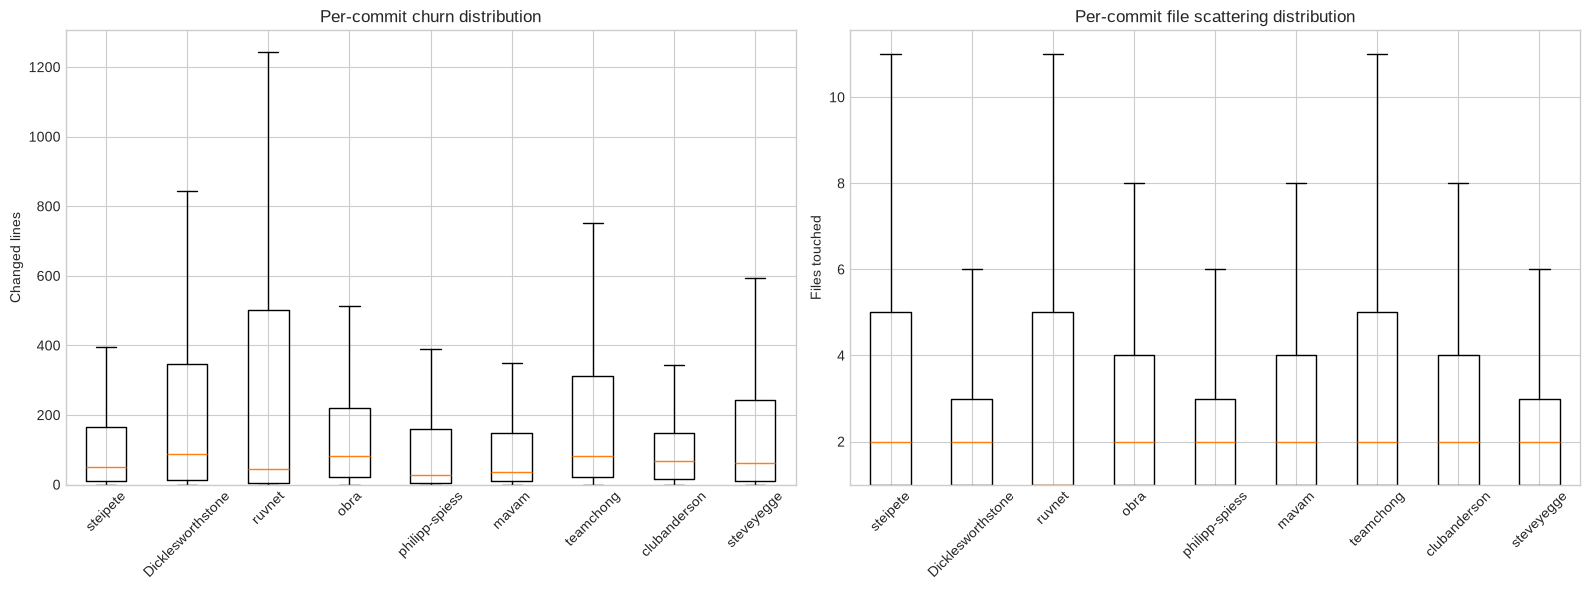

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

churn_series = [analysis.loc[analysis.developer == dev, "churn"] for dev in developers]
file_series = [analysis.loc[analysis.developer == dev, "files_touched"] for dev in developers]

axes[0].boxplot(churn_series, tick_labels=developers, showfliers=False)
axes[0].set_title("Per-commit churn distribution")
axes[0].set_ylabel("Changed lines")
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis="x", rotation=45)

axes[1].boxplot(file_series, tick_labels=developers, showfliers=False)
axes[1].set_title("Per-commit file scattering distribution")
axes[1].set_ylabel("Files touched")
axes[1].set_ylim(bottom=1)
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Daily evolution of churn and scattering

These plots summarize the distribution of **per-commit** churn and file scattering on each UTC observation day. The solid line is the daily median, the dashed line is the daily mean, and the shaded band spans p25–p75. Days without analyzable commits remain gaps rather than being interpreted as zero-churn days.

The combined-cohort view pools all commits made by all developers on each day, so it is intentionally weighted by developer commit volume. The small multiples apply the same calculation independently to each developer.

In [10]:
OBSERVATION_DAYS = pd.date_range(START_DATE, END_DATE, freq="D")

def daily_metric_summary(
    frame: pd.DataFrame, metric: str, developer: str | None = None
) -> pd.DataFrame:
    selected = frame if developer is None else frame.loc[frame["developer"] == developer]
    grouped = selected.groupby("day")[metric]
    daily = grouped.agg(mean="mean", median="median")
    daily["p25"] = grouped.quantile(0.25)
    daily["p75"] = grouped.quantile(0.75)
    return daily.reindex(OBSERVATION_DAYS).rename_axis("day")

def plot_daily_evolution(
    ax: plt.Axes, daily: pd.DataFrame, title: str, ylabel: str, numeric_minimum: int = 0
) -> None:
    dates = daily.index.to_numpy()
    ax.fill_between(
        dates,
        daily["p25"].to_numpy(dtype=float),
        daily["p75"].to_numpy(dtype=float),
        color="#457b9d",
        alpha=0.20,
        label="p25–p75",
    )
    ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.5, label="median")
    ax.plot(dates, daily["mean"], color="#e76f51", linewidth=1.1, linestyle="--", label="mean")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(START_DATE, END_DATE)
    ax.set_ylim(bottom=numeric_minimum)
    ax.tick_params(axis="x", rotation=30)

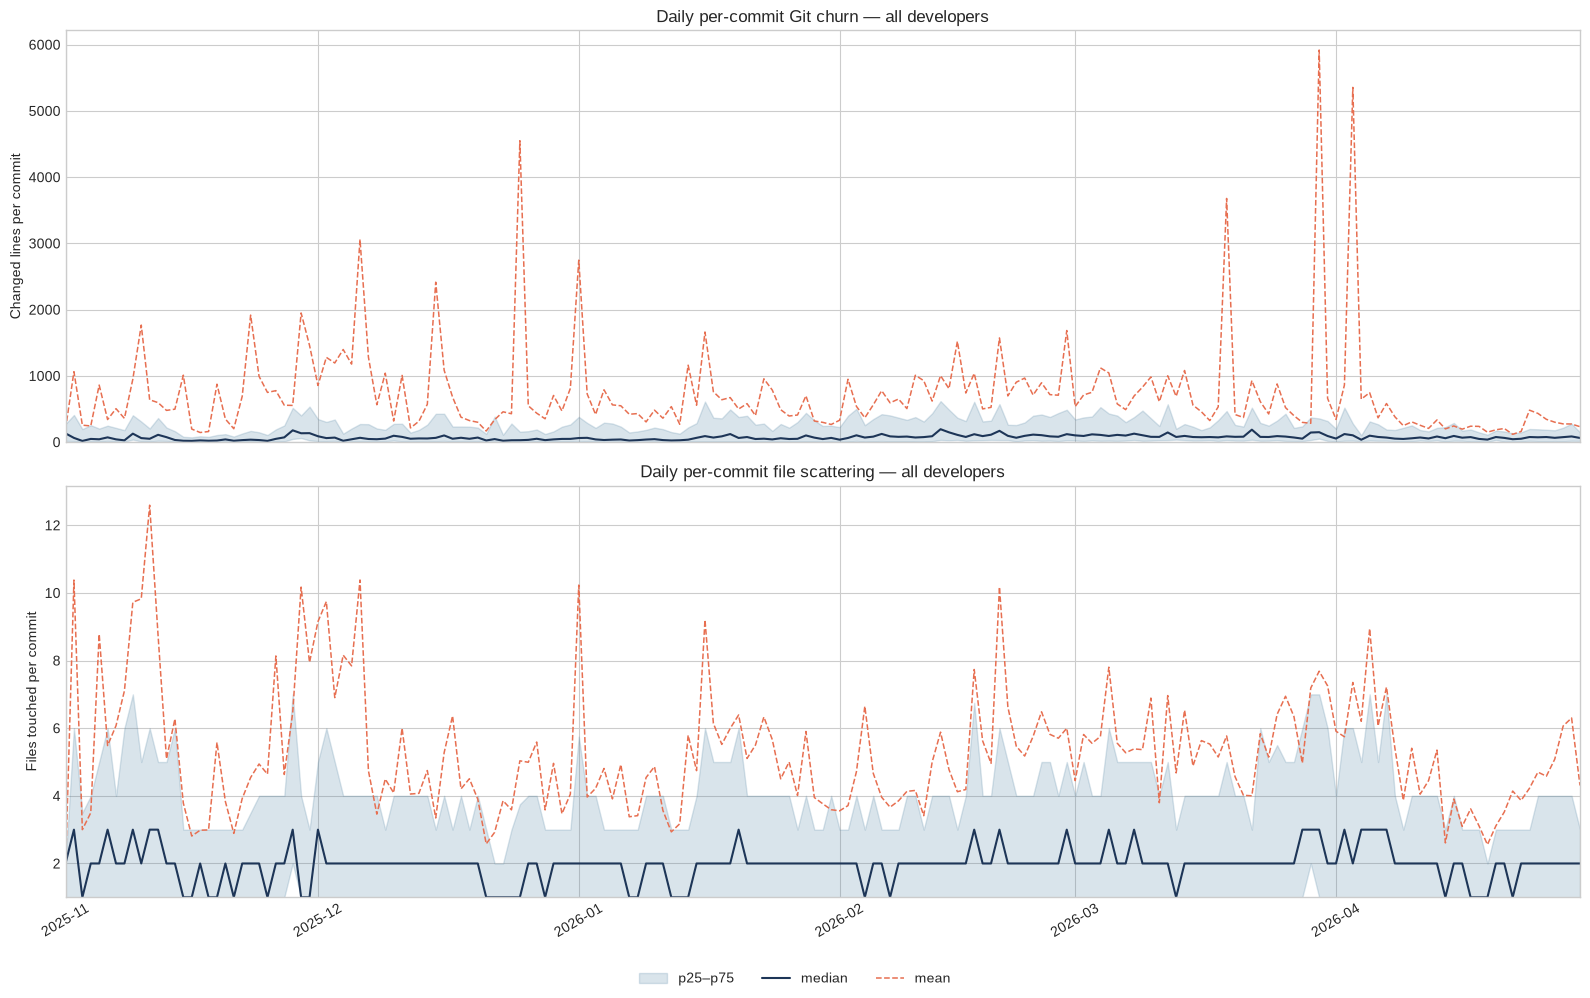

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

plot_daily_evolution(
    axes[0],
    daily_metric_summary(analysis, "churn"),
    "Daily per-commit Git churn — all developers",
    "Changed lines per commit",
)
plot_daily_evolution(
    axes[1],
    daily_metric_summary(analysis, "files_touched"),
    "Daily per-commit file scattering — all developers",
    "Files touched per commit",
    numeric_minimum=1,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Merge-commit sensitivity check

A merge diff may repeat changes already represented by its constituent commits. The table below reports totals with and without merge commits so the impact of that methodological choice is explicit.

In [12]:
def sensitivity_totals(frame: pd.DataFrame, label: str) -> dict:
    return {
        "policy": label,
        "commits": len(frame),
        "additions": frame["additions"].sum(),
        "deletions": frame["deletions"].sum(),
        "gross_churn": frame["churn"].sum(),
        "file_touches": frame["files_touched"].sum(),
    }

cached = commits.loc[commits["cache_present"]].copy()
sensitivity = pd.DataFrame([
    sensitivity_totals(cached, "including merges"),
    sensitivity_totals(cached.loc[~cached["is_merge"]], "excluding merges"),
]).set_index("policy")
display(sensitivity.style.format("{:,}"))

,commits,additions,deletions,gross_churn,file_touches
policy,,,,,
including merges,"143,996","75,895,109","21,081,895","96,977,004","715,672"
excluding merges,"141,129","69,099,467","20,178,805","89,278,272","673,321"


## Interpretation caveats

1. Statistics cover all **embedded commit records**, not unsampled commits represented only by a daily `total_count`. Exact churn cannot be inferred without their SHAs and diffs.
2. A cache entry with no files may represent a genuine empty commit or an unavailable/deleted repository; it is retained as zero but counted in the audit.
3. The collector did not paginate commit details. Cached commits containing exactly 300 files may therefore have truncated file lists, making their churn and scattering lower bounds. GitHub's REST endpoint can be paginated to 3,000 files; 300 is not the absolute API limit.
4. Raw churn includes generated files, lockfiles, vendored code, and data. Filtering those categories would answer a different question and should be reported as a separate sensitivity analysis.
5. Means are especially sensitive to very large commits. Prefer medians and interquartile ranges when describing a typical commit.

## Alternative readable aggregate and developer comparisons

The following visualizations supplement the preceding plots without replacing them. The aggregate views focus on the median and interquartile band so that extreme commits do not hide the typical commit. Churn axes start at zero; file-touch axes start at one.

For individual comparisons, eight developers use exactly the same **2025-11-01 to 2026-04-30 time axis**, tick positions, and numeric Y range. `ruvnet` appears in a separate full-width panel with the same dates but an independent Y range because its churn and scattering are on a substantially different scale.

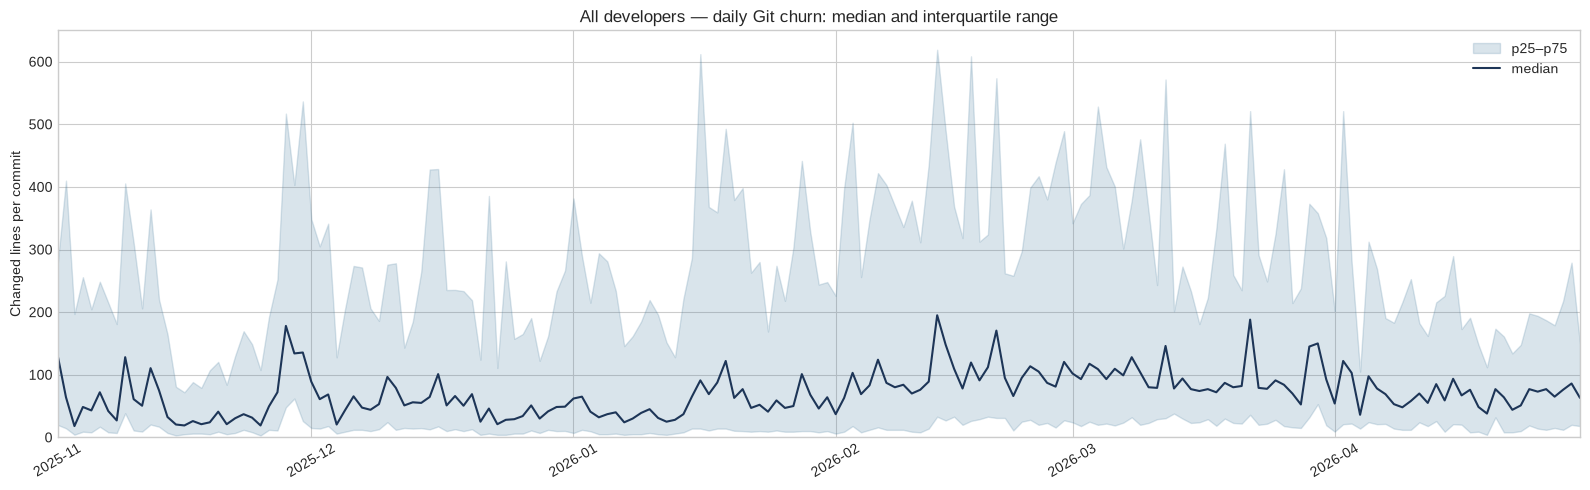

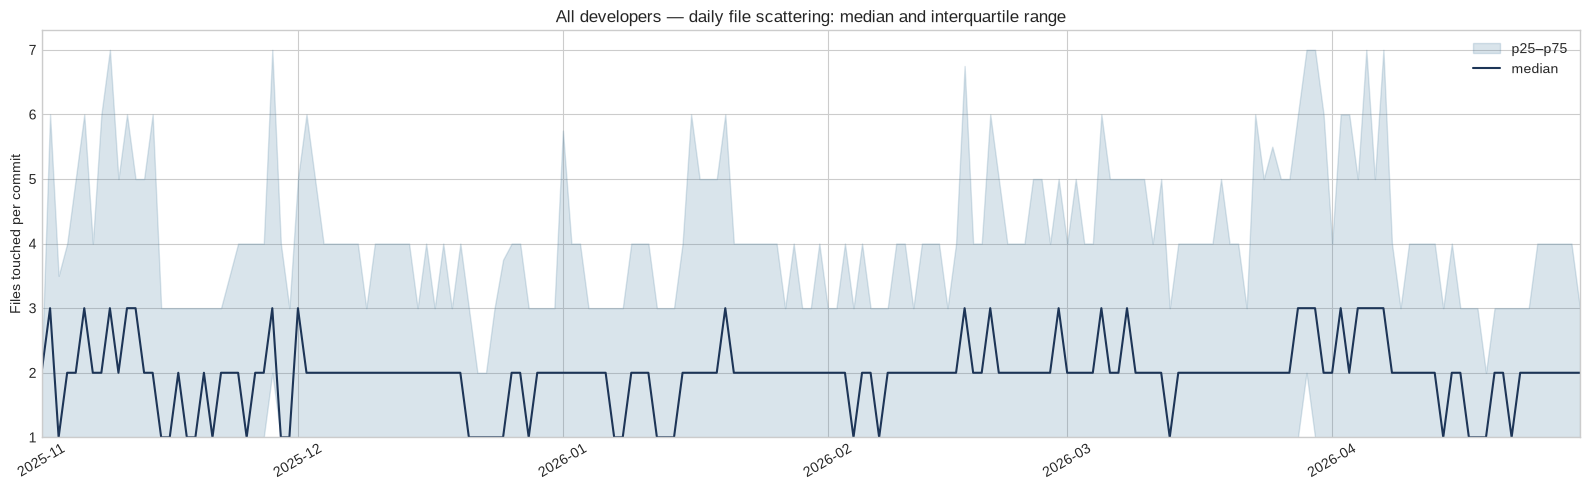

In [13]:
from matplotlib import dates as mdates

def plot_aggregate_metric_central(metric: str, ylabel: str, heading: str) -> None:
    daily = daily_metric_summary(analysis, metric)
    dates = daily.index.to_numpy()
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.fill_between(
        dates, daily["p25"].to_numpy(dtype=float), daily["p75"].to_numpy(dtype=float),
        color="#457b9d", alpha=0.20, label="p25–p75",
    )
    ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.5, label="median")
    ax.set_title(f"{heading}: median and interquartile range")
    ax.set_ylabel(ylabel)
    ax.set_xlim(START_DATE, END_DATE)
    ax.set_ylim(bottom=1 if metric == "files_touched" else 0)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

plot_aggregate_metric_central("churn", "Changed lines per commit", "All developers — daily Git churn")
plot_aggregate_metric_central("files_touched", "Files touched per commit", "All developers — daily file scattering")

## Per-developer evolution of churn and scattering

The aggregate views above pool the whole cohort, which hides who drives a given movement. The two figures below apply exactly the same daily calculation to each developer, one row per developer: churn first, file scattering second. As above, the solid line is the daily median, the dashed line is the daily mean, and the shaded band spans p25–p75. Days without analyzable commits stay gaps.

The eight comparable developers share the same time axis, tick positions, and Y range within a figure, so their rows can be read against one another directly. That shared Y range covers the bulk of the daily statistics rather than their extremes, because a single day carrying one very large commit would otherwise flatten every other panel; each panel reports how many days run past the top of its axis. `ruvnet` is an order of magnitude larger on both metrics, so its row keeps an independent Y range and is outlined in red — its curves must not be compared by eye to the rows above.


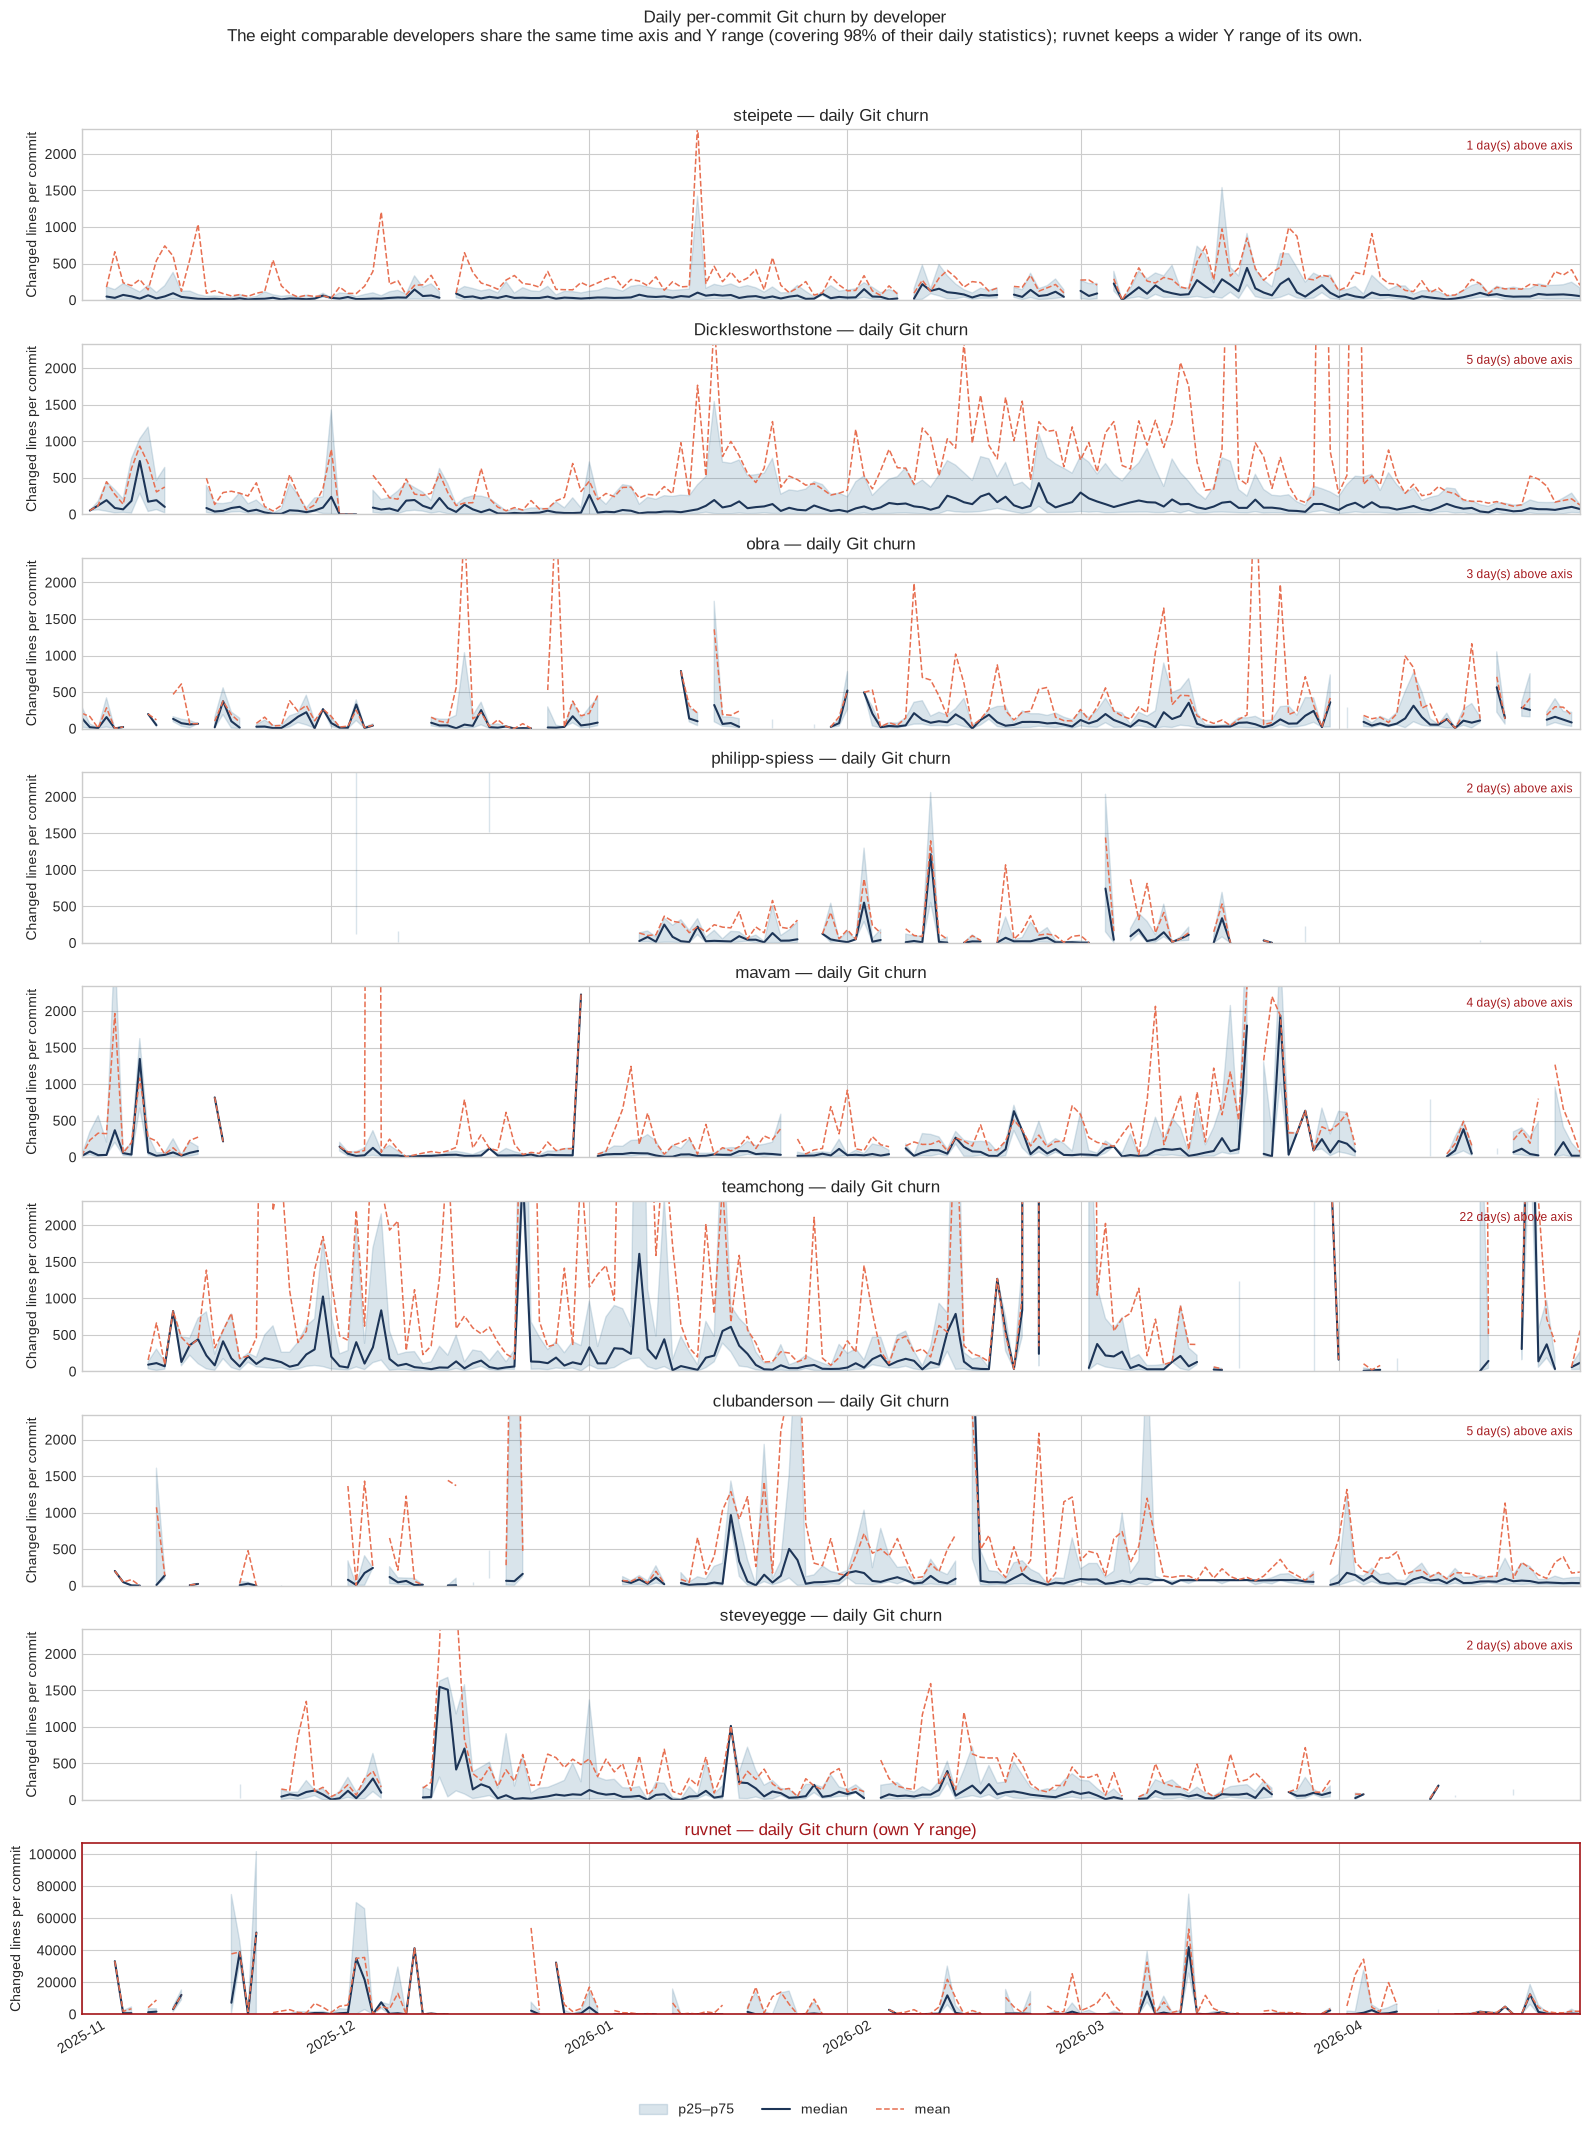

In [14]:
OUTLIER_DEVELOPER = "ruvnet"
SHARED_DEVELOPERS = [developer for developer in developers if developer != OUTLIER_DEVELOPER]
PANEL_ORDER = SHARED_DEVELOPERS + [OUTLIER_DEVELOPER]

# A single day dominated by one very large commit would otherwise flatten every
# other panel, so the shared Y range covers the bulk of the daily statistics and
# each panel reports how many days run off the top of its axis.
SHARED_COVERAGE = 0.98
PLOTTED_STATISTICS = ["mean", "median", "p75"]

def upper_limit(frames: list[pd.DataFrame], coverage: float) -> float:
    plotted = pd.concat([frame[PLOTTED_STATISTICS].stack() for frame in frames])
    return float(plotted.quantile(coverage)) * 1.05

def plot_developer_small_multiples(
    metric: str, ylabel: str, heading: str, numeric_minimum: int = 0
) -> None:
    daily_by_developer = {
        developer: daily_metric_summary(analysis, metric, developer)
        for developer in PANEL_ORDER
    }
    shared_upper = upper_limit(
        [daily_by_developer[developer] for developer in SHARED_DEVELOPERS], SHARED_COVERAGE
    )
    outlier_upper = upper_limit([daily_by_developer[OUTLIER_DEVELOPER]], 1.0)

    fig, axes = plt.subplots(
        len(PANEL_ORDER), 1, figsize=(16, 2.4 * len(PANEL_ORDER)), sharex=True
    )

    for ax, developer in zip(axes, PANEL_ORDER):
        is_outlier = developer == OUTLIER_DEVELOPER
        daily = daily_by_developer[developer]
        upper = outlier_upper if is_outlier else shared_upper
        plot_daily_evolution(
            ax,
            daily,
            f"{developer} — daily {heading}" + (" (own Y range)" if is_outlier else ""),
            ylabel,
            numeric_minimum=numeric_minimum,
        )
        ax.set_ylim(numeric_minimum, upper)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

        above_axis = int((daily[PLOTTED_STATISTICS] > upper).any(axis=1).sum())
        if above_axis:
            ax.text(
                0.995, 0.90, f"{above_axis} day(s) above axis",
                transform=ax.transAxes, ha="right", va="center", fontsize=8.5,
                color="#a4161a",
            )
        if is_outlier:
            ax.title.set_color("#a4161a")
            for spine in ax.spines.values():
                spine.set_edgecolor("#a4161a")
                spine.set_linewidth(1.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    fig.suptitle(
        f"Daily per-commit {heading} by developer\n"
        f"The eight comparable developers share the same time axis and Y range "
        f"(covering {SHARED_COVERAGE:.0%} of their daily statistics); "
        f"{OUTLIER_DEVELOPER} keeps a wider Y range of its own.",
        fontsize=12,
    )
    fig.tight_layout(rect=(0, 0.025, 1, 0.965))
    plt.show()

plot_developer_small_multiples("churn", "Changed lines per commit", "Git churn")

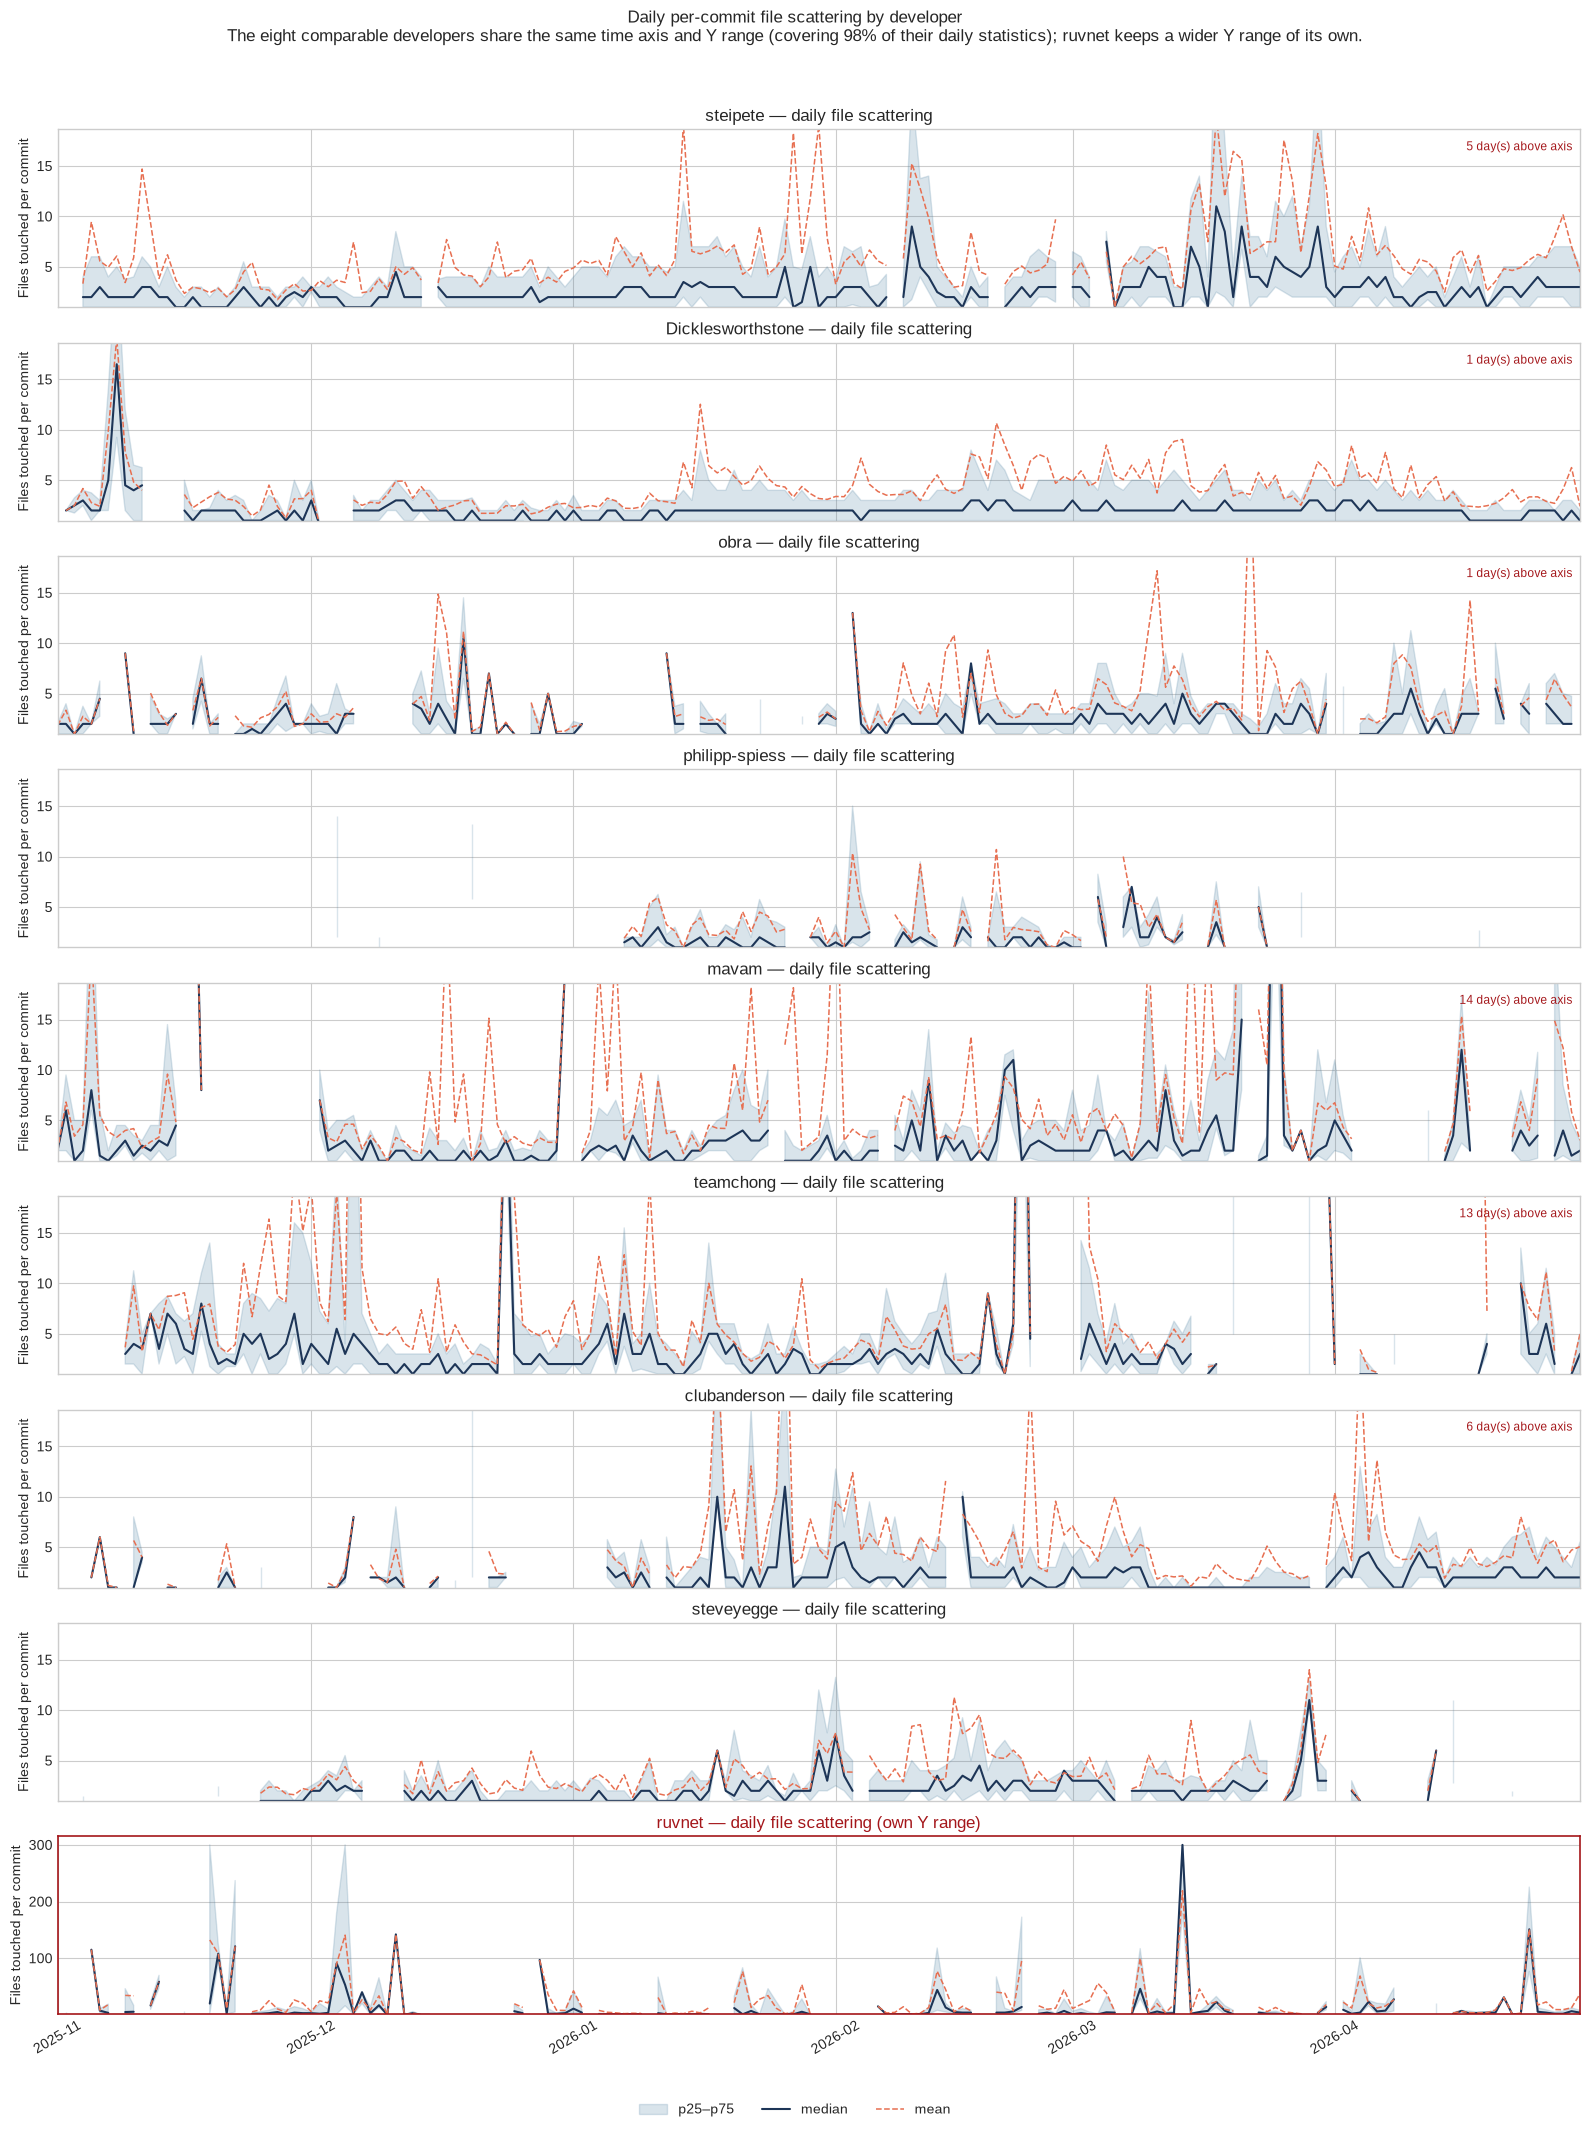

In [15]:
plot_developer_small_multiples(
    "files_touched", "Files touched per commit", "file scattering", numeric_minimum=1
)

## Commit breadth, daily volume, and file revisits

Churn and file scattering describe how much a commit changes. Two further measures describe how that change is placed. *Breadth* counts the distinct top-level directories, or modules, a commit spans, and is reported alongside the daily volume in which commits are produced, including whether a busier day is made of smaller commits (`rho_commits_median_churn`) or simply of more of them (`rho_commits_daily_churn`).

A *revisit* is a change to a file the same developer already changed earlier in the window, in the same repository. High revisit rates indicate that output concentrates on recently written code. Agent state files, such as in-repository issue trackers and agent memory, are rewritten by tooling on nearly every commit, so their share is reported next to the revisit rates they inflate.


In [16]:
PAPER_FIGURE_DIR = ROOT / "paper" / "figures" / "rq4"
EXPORT_DIR = DATA_DIR / "rq4"
RECENT_REWORK_DAYS = 7

def breadth_table() -> pd.DataFrame:
    daily = analysis.groupby(["developer", "day"]).agg(
        commits=("sha", "size"), churn=("churn", "sum")
    )
    grouped = analysis.groupby("developer")
    table = pd.DataFrame({
        "commits": grouped["sha"].size(),
        "median_files": grouped["files_touched"].median(),
        "p95_files": grouped["files_touched"].quantile(0.95),
        "median_modules": grouped["modules"].median(),
        "mean_modules": grouped["modules"].mean(),
        "multi_module_share": grouped["modules"].apply(lambda values: (values > 1).mean()),
        "focused_share": grouped["files_touched"].apply(lambda values: (values <= 5).mean()),
        "scattered_share": grouped["files_touched"].apply(lambda values: (values > 10).mean()),
        "active_days": daily.groupby("developer")["commits"].size(),
        "median_commits_per_day": daily.groupby("developer")["commits"].median(),
        "median_daily_churn": daily.groupby("developer")["churn"].median(),
        "p95_daily_churn": daily.groupby("developer")["churn"].quantile(0.95),
    })
    # Does a busier day consist of smaller commits, or simply of more of them?
    per_day = analysis.groupby(["developer", "day"]).agg(
        commits=("sha", "size"), median_churn=("churn", "median"), churn=("churn", "sum")
    )
    table["rho_commits_median_churn"] = per_day.groupby("developer").apply(
        lambda frame: frame["commits"].rank().corr(frame["median_churn"].rank())
    )
    table["rho_commits_daily_churn"] = per_day.groupby("developer").apply(
        lambda frame: frame["commits"].rank().corr(frame["churn"].rank())
    )
    return table.reindex(developers)

breadth = breadth_table()
display(breadth.style.format({
    "commits": "{:,.0f}", "median_files": "{:,.0f}", "p95_files": "{:,.0f}",
    "median_modules": "{:,.0f}", "mean_modules": "{:,.2f}",
    "multi_module_share": "{:.1%}", "focused_share": "{:.1%}", "scattered_share": "{:.1%}",
    "active_days": "{:,.0f}", "median_commits_per_day": "{:,.0f}",
    "median_daily_churn": "{:,.0f}", "p95_daily_churn": "{:,.0f}",
    "rho_commits_median_churn": "{:.2f}", "rho_commits_daily_churn": "{:.2f}",
}))

,commits,median_files,p95_files,median_modules,mean_modules,multi_module_share,focused_share,scattered_share,active_days,median_commits_per_day,median_daily_churn,p95_daily_churn,rho_commits_median_churn,rho_commits_daily_churn
developer,,,,,,,,,,,,,,
steipete,"35,089",2,17,1,1.56,34.9%,78.0%,10.0%,173,188,"39,867","192,799",-0.05,0.84
Dicklesworthstone,"70,843",2,12,1,1.44,30.8%,86.1%,6.2%,176,304,"147,294","947,269",0.13,0.83
ruvnet,"5,383",1,55,1,1.49,24.1%,76.4%,13.9%,141,15,"46,458","372,238",-0.41,0.56
obra,"4,419",2,11,1,1.60,41.3%,84.0%,5.7%,144,20,"4,091","43,595",0.24,0.84
philipp-spiess,808,2,12,1,1.33,23.5%,84.3%,6.3%,73,7,"1,596","7,902",-0.02,0.73
mavam,"2,685",2,20,1,1.56,33.5%,80.0%,10.9%,152,13,"3,084","22,862",-0.30,0.66
teamchong,"7,204",2,16,1,1.47,30.6%,79.8%,8.7%,141,31,"22,408","248,764",-0.33,0.63
clubanderson,"8,536",2,14,1,1.20,15.3%,83.6%,7.3%,143,46,"12,283","68,637",-0.06,0.71
steveyegge,"9,029",2,10,1,1.26,16.2%,89.0%,4.4%,129,46,"12,096","122,074",-0.15,0.86


In [17]:
def revisit_table() -> pd.DataFrame:
    ordered = file_touches.sort_values(["developer", "repository", "filename", "day"])
    grouped = ordered.groupby(["developer", "repository", "filename"], sort=False)
    ordered = ordered.assign(gap_days=(ordered["day"] - grouped["day"].shift()).dt.days)

    records = []
    for developer, frame in ordered.groupby("developer", sort=False):
        distinct = frame.groupby(["repository", "filename"], sort=False).ngroups
        records.append({
            "developer": developer,
            "file_touches": len(frame),
            "distinct_files": distinct,
            "touches_per_file": len(frame) / distinct,
            "revisit_share": frame["gap_days"].notna().mean(),
            "revisit_within_week": (frame["gap_days"] <= RECENT_REWORK_DAYS).mean(),
            "revisit_same_day": (frame["gap_days"] == 0).mean(),
            # Agent state is rewritten by tooling on nearly every commit, so it is
            # reported next to the revisit rates it inflates.
            "agent_state_touch_share": frame["filename"].str.contains(AGENT_STATE).mean(),
            "agent_state_churn_share": (
                frame.loc[frame["filename"].str.contains(AGENT_STATE), "churn"].sum()
                / max(frame["churn"].sum(), 1)
            ),
        })
    return pd.DataFrame(records).set_index("developer").reindex(developers)

# Directories and files that coding agents maintain as their own state inside the
# repository: issue trackers, memory files, and agent instructions.
AGENT_STATE = re.compile(
    r"(^|/)\.(beads|claude|cursor|specstory|aider|codex|opencode|agent|agents|ruvector|swarm|roo|windsurf)(/|$)"
    r"|(^|/)(AGENTS?|CLAUDE|GEMINI|CODEX)\.md$",
    re.I,
)

revisits = revisit_table()
display(revisits.style.format({
    "file_touches": "{:,.0f}", "distinct_files": "{:,.0f}", "touches_per_file": "{:,.2f}",
    "revisit_share": "{:.1%}", "revisit_within_week": "{:.1%}", "revisit_same_day": "{:.1%}",
    "agent_state_touch_share": "{:.1%}", "agent_state_churn_share": "{:.1%}",
}))

/tmp/ipykernel_1431599/1971728788.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "agent_state_touch_share": frame["filename"].str.contains(AGENT_STATE).mean(),


/tmp/ipykernel_1431599/1971728788.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frame.loc[frame["filename"].str.contains(AGENT_STATE), "churn"].sum()


,file_touches,distinct_files,touches_per_file,revisit_share,revisit_within_week,revisit_same_day,agent_state_touch_share,agent_state_churn_share
developer,,,,,,,,
steipete,"193,148","38,917",4.96,79.9%,67.1%,40.3%,0.6%,0.2%
Dicklesworthstone,"306,906","78,487",3.91,74.4%,64.9%,43.3%,10.5%,7.1%
ruvnet,"64,147","26,015",2.47,59.4%,53.9%,44.9%,11.3%,20.9%
obra,"19,334","5,674",3.41,70.7%,64.6%,45.7%,0.5%,0.2%
philipp-spiess,"2,943","1,034",2.85,64.9%,56.2%,28.4%,1.1%,0.2%
mavam,"18,987","8,308",2.29,56.2%,44.9%,26.0%,2.8%,1.0%
teamchong,"42,139","12,889",3.27,69.4%,64.1%,39.5%,0.0%,0.1%
clubanderson,"38,012","10,091",3.77,73.5%,61.0%,32.4%,0.3%,0.1%
steveyegge,"30,056","3,570",8.42,88.1%,76.8%,42.0%,15.4%,51.8%


## Export the figures and tables used in the paper

This section is the single source of the RQ4 material in `paper/`. It writes `paper/figures/rq4/churn-evolution.pdf` and `scattering-evolution.pdf`, sized and labeled for the paper column, together with `data/rq4/commit-breadth.csv`, `data/rq4/rework.csv`, and `data/rq4/tables.tex`, which holds the LaTeX bodies of the two tables. The paper figures show the median and the interquartile band only; the exploratory versions above additionally show the daily mean.


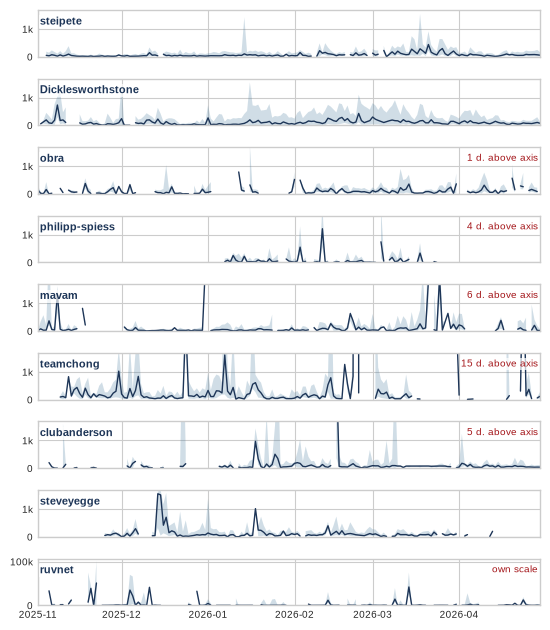

wrote /home/dig/repositories/what-are-they-doing/paper/figures/rq4/churn-evolution.pdf


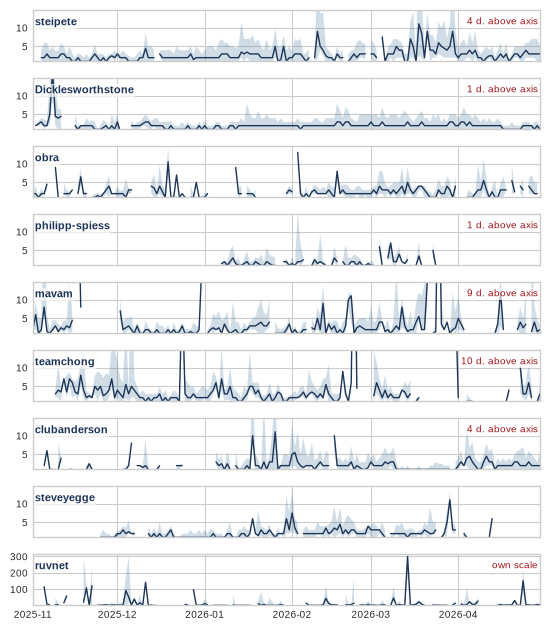

wrote /home/dig/repositories/what-are-they-doing/paper/figures/rq4/scattering-evolution.pdf
wrote /home/dig/repositories/what-are-they-doing/data/rq4/commit-breadth.csv, /home/dig/repositories/what-are-they-doing/data/rq4/rework.csv, /home/dig/repositories/what-are-they-doing/data/rq4/tables.tex


In [18]:
from matplotlib.ticker import FuncFormatter

PAPER_FIGURE_SIZE = (5.6, 6.4)
PAPER_NOTE_COLOR = "#a4161a"

def export_paper_figure(metric: str, filename: str, numeric_minimum: int = 0) -> None:
    """Write the paper version of a per-developer small-multiples figure.

    Developer names are drawn inside their panel so that the plotting area spans
    the full width of the page; the unit of the Y axis is given in the caption.
    The paper version shows the median and the interquartile band only.
    """
    daily_by_developer = {
        developer: daily_metric_summary(analysis, metric, developer)
        for developer in PANEL_ORDER
    }
    statistics = ["median", "p75"]

    def limit(frames: list[pd.DataFrame], coverage: float) -> float:
        plotted = pd.concat([frame[statistics].stack() for frame in frames])
        return float(plotted.quantile(coverage)) * 1.05

    shared_upper = limit(
        [daily_by_developer[developer] for developer in SHARED_DEVELOPERS], SHARED_COVERAGE
    )
    outlier_upper = limit([daily_by_developer[OUTLIER_DEVELOPER]], 1.0)

    fig, axes = plt.subplots(len(PANEL_ORDER), 1, figsize=PAPER_FIGURE_SIZE, sharex=True)
    for ax, developer in zip(axes, PANEL_ORDER):
        is_outlier = developer == OUTLIER_DEVELOPER
        daily = daily_by_developer[developer]
        upper = outlier_upper if is_outlier else shared_upper
        dates = daily.index.to_numpy()

        ax.fill_between(
            dates, daily["p25"].to_numpy(dtype=float), daily["p75"].to_numpy(dtype=float),
            color="#457b9d", alpha=0.25, linewidth=0,
        )
        ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.0)
        ax.set_xlim(START_DATE, END_DATE)
        ax.set_ylim(numeric_minimum, upper)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda value, _: f"{value:,.0f}" if value < 1000 else f"{value / 1000:,.0f}k"
        ))
        ax.tick_params(labelsize=7.5)
        ax.text(
            0.004, 0.86, developer, transform=ax.transAxes, ha="left", va="top",
            fontsize=8, fontweight="bold", color="#1d3557",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0),
        )

        above_axis = int((daily[statistics] > upper).any(axis=1).sum())
        note = f"{above_axis} d. above axis" if above_axis else ""
        if is_outlier:
            note = "own scale" + (f", {note}" if note else "")
        if note:
            ax.text(
                0.996, 0.86, note, transform=ax.transAxes, ha="right", va="top",
                fontsize=7, color=PAPER_NOTE_COLOR,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0),
            )

    fig.tight_layout(rect=(0, 0, 1, 1))
    PAPER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(PAPER_FIGURE_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"wrote {PAPER_FIGURE_DIR / filename}")

def latex_number(value: float, decimals: int = 0) -> str:
    return f"{value:,.{decimals}f}".replace(",", "\\,")

def latex_tables(breadth: pd.DataFrame, revisits: pd.DataFrame) -> str:
    lines = ["% Generated by script/git-statistics/git-statistics.ipynb", "% Breadth and daily volume"]
    for developer, row in breadth.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.commits)} & {latex_number(row.median_files)} & "
            f"{latex_number(row.p95_files)} & {latex_number(row.median_modules)} & "
            f"{latex_number(row.mean_modules, 2)} & {row.multi_module_share * 100:.1f} & "
            f"{row.focused_share * 100:.1f} & {row.scattered_share * 100:.1f} & "
            f"{latex_number(row.active_days)} & {latex_number(row.median_commits_per_day)} & "
            f"{latex_number(row.median_daily_churn)} \\\\"
        )
    lines.append("% File revisits")
    for developer, row in revisits.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.file_touches)} & "
            f"{latex_number(row.distinct_files)} & {row.touches_per_file:.2f} & "
            f"{row.revisit_share * 100:.1f} & {row.revisit_within_week * 100:.1f} & "
            f"{row.revisit_same_day * 100:.1f} \\\\"
        )
    return "\n".join(lines) + "\n"

export_paper_figure("churn", "churn-evolution.pdf")
export_paper_figure("files_touched", "scattering-evolution.pdf", numeric_minimum=1)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
breadth.to_csv(EXPORT_DIR / "commit-breadth.csv")
revisits.to_csv(EXPORT_DIR / "rework.csv")
(EXPORT_DIR / "tables.tex").write_text(latex_tables(breadth, revisits))
print(f"wrote {EXPORT_DIR / 'commit-breadth.csv'}, {EXPORT_DIR / 'rework.csv'}, {EXPORT_DIR / 'tables.tex'}")

## Main outlier commits

Percentile curves compress the upper tail and can be difficult to interpret for these highly skewed distributions. The tables below instead identify the concrete commits driving the extremes. They show the ten largest commits across the cohort and the five largest for every developer, ranked separately by additions, deletions, gross churn, and files touched. Each row links to the commit on GitHub.

A cached value of 300 files should be treated as a possible lower bound because the collector retained only the first REST response. GitHub pagination supports up to 3,000 files, while the independent Git calculation below has no corresponding API-page ceiling.

In [19]:
OUTLIER_COLUMNS = [
    "developer", "day", "repository", "sha",
    "additions", "deletions", "churn", "files_touched", "commit_url",
]

def ranked_outliers(frame: pd.DataFrame, metric: str, count: int) -> pd.DataFrame:
    ranked = frame.copy()
    ranked["commit_url"] = ranked.apply(
        lambda row: (
            f"https://github.com/{row['repository']}/commit/{row['sha']}"
            if pd.notna(row["repository"]) else None
        ),
        axis=1,
    )
    ranked = ranked.sort_values(
        [metric, "churn", "files_touched", "day", "sha"],
        ascending=[False, False, False, True, True],
    ).head(count)
    return ranked[OUTLIER_COLUMNS].reset_index(drop=True)

def display_outliers(table: pd.DataFrame) -> None:
    display(table.style.format(
        {
            "day": lambda value: value.strftime("%Y-%m-%d"),
            "additions": "{:,.0f}",
            "deletions": "{:,.0f}",
            "churn": "{:,.0f}",
            "files_touched": "{:,.0f}",
        },
        hyperlinks="html",
    ))

OUTLIER_CATEGORIES = [
    ("additions", "Commits adding the most lines"),
    ("deletions", "Commits deleting the most lines"),
    ("churn", "Largest commits by gross churn"),
    ("files_touched", "Commits touching the most files"),
]

for metric, label in OUTLIER_CATEGORIES:
    print(f"{label} — all developers")
    display_outliers(ranked_outliers(analysis, metric, 10))

    print(f"{label} — top five per developer")
    per_developer = pd.concat(
        [ranked_outliers(analysis.loc[analysis["developer"] == developer], metric, 5) for developer in developers],
        ignore_index=True,
    )
    display_outliers(per_developer)

assert analysis["churn"].ge(0).all() and analysis["files_touched"].ge(0).all()
assert per_developer["commit_url"].str.startswith("https://github.com/").all()

Commits adding the most lines — all developers


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,Dicklesworthstone,2026-02-15,Dicklesworthstone/frankenlibc,fc9fcae7ad386fcb40af1867a6e0ae569a650907,"1,700,861",8,"1,700,869",7,https://github.com/Dicklesworthstone/frankenlibc/commit/fc9fcae7ad386fcb40af1867a6e0ae569a650907
1,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"1,693,521",39,"1,693,560",300,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
2,Dicklesworthstone,2026-02-10,Dicklesworthstone/frankenterm,e6303733ef911cf7eae8e6c0569a963049315f8c,"773,674",4,"773,678",298,https://github.com/Dicklesworthstone/frankenterm/commit/e6303733ef911cf7eae8e6c0569a963049315f8c
3,Dicklesworthstone,2026-03-30,Dicklesworthstone/frankenmermaid,921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6,"729,424",155,"729,579",146,https://github.com/Dicklesworthstone/frankenmermaid/commit/921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6
4,ruvnet,2025-12-25,subnirvake/vector-sh,ae4961ec53f1fe37f14b176763bd8a48974c1ade,"603,850",42,"603,892",45,https://github.com/subnirvake/vector-sh/commit/ae4961ec53f1fe37f14b176763bd8a48974c1ade
5,ruvnet,2025-12-25,subnirvake/vector-sh,d294274a6a37057e805f806d765bdcb0cf3e01b8,"603,850",42,"603,892",45,https://github.com/subnirvake/vector-sh/commit/d294274a6a37057e805f806d765bdcb0cf3e01b8
6,ruvnet,2025-12-25,subnirvake/vector-sh,4a565ecd21ac60bb53ef2330ba7d9af6000eea41,"581,900",12,"581,912",27,https://github.com/subnirvake/vector-sh/commit/4a565ecd21ac60bb53ef2330ba7d9af6000eea41
7,ruvnet,2025-12-25,subnirvake/vector-sh,a92557e96f36190ff6895d15feb70badaff94def,"581,900",12,"581,912",27,https://github.com/subnirvake/vector-sh/commit/a92557e96f36190ff6895d15feb70badaff94def
8,ruvnet,2026-04-03,ruvnet/RuVector,ac0b9ff7b9b6a1721140ca59be70654ba6745a07,"564,425","401,282","965,707",157,https://github.com/ruvnet/RuVector/commit/ac0b9ff7b9b6a1721140ca59be70654ba6745a07
9,ruvnet,2026-04-03,ruvnet/RuVector,e39b5901c1941929be023aa35b22f75c97719520,"531,716","31,893","563,609",225,https://github.com/ruvnet/RuVector/commit/e39b5901c1941929be023aa35b22f75c97719520


Commits adding the most lines — top five per developer


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2025-12-07,openclaw/openclaw,98651c2a141793360c9690c82061b1a2028f48f2,"195,780",142,"195,922",10,https://github.com/openclaw/openclaw/commit/98651c2a141793360c9690c82061b1a2028f48f2
1,steipete,2026-04-05,openclaw/docs,aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d,"70,932",4,"70,936",300,https://github.com/openclaw/docs/commit/aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d
2,steipete,2026-04-05,openclaw/docs,b2c5c80ac76290678dc24bc36f0f1053705bd2cb,"61,633",0,"61,633",300,https://github.com/openclaw/docs/commit/b2c5c80ac76290678dc24bc36f0f1053705bd2cb
3,steipete,2025-12-17,openclaw/openclaw,cdb5ddb2da0b0b3ed3af4f953ffbceea8411f868,"48,775",32,"48,807",300,https://github.com/openclaw/openclaw/commit/cdb5ddb2da0b0b3ed3af4f953ffbceea8411f868
4,steipete,2025-11-24,steipete/RepoBar,b7af69dc4a0c9df88ec5b57e48bb4fb237ab0862,"47,752",11,"47,763",300,https://github.com/steipete/RepoBar/commit/b7af69dc4a0c9df88ec5b57e48bb4fb237ab0862
5,Dicklesworthstone,2026-02-15,Dicklesworthstone/frankenlibc,fc9fcae7ad386fcb40af1867a6e0ae569a650907,"1,700,861",8,"1,700,869",7,https://github.com/Dicklesworthstone/frankenlibc/commit/fc9fcae7ad386fcb40af1867a6e0ae569a650907
6,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"1,693,521",39,"1,693,560",300,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
7,Dicklesworthstone,2026-02-10,Dicklesworthstone/frankenterm,e6303733ef911cf7eae8e6c0569a963049315f8c,"773,674",4,"773,678",298,https://github.com/Dicklesworthstone/frankenterm/commit/e6303733ef911cf7eae8e6c0569a963049315f8c
8,Dicklesworthstone,2026-03-30,Dicklesworthstone/frankenmermaid,921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6,"729,424",155,"729,579",146,https://github.com/Dicklesworthstone/frankenmermaid/commit/921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6
9,Dicklesworthstone,2026-02-02,Dicklesworthstone/frankentui,c563e29e36ff3267f62e35b3ba3e80114a466882,"478,279",340,"478,619",104,https://github.com/Dicklesworthstone/frankentui/commit/c563e29e36ff3267f62e35b3ba3e80114a466882


Commits deleting the most lines — all developers


...

,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2025-11-15,steipete/Peekaboo,80d979adf8c9f8ec2677a62712589117abe2bc07,0,"295,380","295,380",1,https://github.com/steipete/Peekaboo/commit/80d979adf8c9f8ec2677a62712589117abe2bc07
1,steipete,2025-12-07,openclaw/openclaw,98651c2a141793360c9690c82061b1a2028f48f2,"195,780",142,"195,922",10,https://github.com/openclaw/openclaw/commit/98651c2a141793360c9690c82061b1a2028f48f2
2,steipete,2026-04-04,openclaw/openclaw,b5265a07d7e0d049925e9c1578892f84b5a2fc86,125,"156,375","156,500",17,https://github.com/openclaw/openclaw/commit/b5265a07d7e0d049925e9c1578892f84b5a2fc86
3,steipete,2026-04-05,openclaw/docs,aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d,"70,932",4,"70,936",300,https://github.com/openclaw/docs/commit/aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d
4,steipete,2026-01-14,openclaw/openclaw,bcbfb357bec72500b304936fd2d37e1acd49edbb,"38,452","30,827","69,279",300,https://github.com/openclaw/openclaw/commit/bcbfb357bec72500b304936fd2d37e1acd49edbb
5,Dicklesworthstone,2026-02-15,Dicklesworthstone/frankenlibc,fc9fcae7ad386fcb40af1867a6e0ae569a650907,"1,700,861",8,"1,700,869",7,https://github.com/Dicklesworthstone/frankenlibc/commit/fc9fcae7ad386fcb40af1867a6e0ae569a650907
6,Dicklesworthstone,2026-03-19,Dicklesworthstone/frankenlibc,2ae73740b12d8d84d939e06b1daf11f2ecb24d03,"5,536","1,695,122","1,700,658",60,https://github.com/Dicklesworthstone/frankenlibc/commit/2ae73740b12d8d84d939e06b1daf11f2ecb24d03
7,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"1,693,521",39,"1,693,560",300,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
8,Dicklesworthstone,2026-02-10,Dicklesworthstone/frankenterm,e6303733ef911cf7eae8e6c0569a963049315f8c,"773,674",4,"773,678",298,https://github.com/Dicklesworthstone/frankenterm/commit/e6303733ef911cf7eae8e6c0569a963049315f8c
9,Dicklesworthstone,2026-03-30,Dicklesworthstone/frankenmermaid,921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6,"729,424",155,"729,579",146,https://github.com/Dicklesworthstone/frankenmermaid/commit/921d885e5a0e0665a7b5c3d9f3dbbcfc655562b6


Commits touching the most files — all developers


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"1,693,521",39,"1,693,560",300,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
1,Dicklesworthstone,2026-03-22,Dicklesworthstone/frankenterm,60764fa56ae3758ef86237a87ba594e015e5f5c7,"370,490",0,"370,490",300,https://github.com/Dicklesworthstone/frankenterm/commit/60764fa56ae3758ef86237a87ba594e015e5f5c7
2,Dicklesworthstone,2026-03-22,Dicklesworthstone/frankenterm,832c7536bd64cdee66645d341e6630ff605a9dc9,0,"370,490","370,490",300,https://github.com/Dicklesworthstone/frankenterm/commit/832c7536bd64cdee66645d341e6630ff605a9dc9
3,Dicklesworthstone,2026-02-06,Dicklesworthstone/pi_agent_rust,e662fb3ed7701b82b854f92e5c923d9724887758,"367,677",172,"367,849",300,https://github.com/Dicklesworthstone/pi_agent_rust/commit/e662fb3ed7701b82b854f92e5c923d9724887758
4,teamchong,2025-11-25,teamchong/metal0,1ae6535864d41714b1f8175d161a37e919169c72,"295,430",5,"295,435",300,https://github.com/teamchong/metal0/commit/1ae6535864d41714b1f8175d161a37e919169c72
5,ruvnet,2026-04-04,ruvnet/RuVector,4afdaceeae998d84bffc9148f01edbf62534badf,"202,332",156,"202,488",300,https://github.com/ruvnet/RuVector/commit/4afdaceeae998d84bffc9148f01edbf62534badf
6,Dicklesworthstone,2026-03-25,Dicklesworthstone/agentic_coding_flywheel_setup,5191de8223e23660c60ea0ed687a99e5df4734d5,5,"185,404","185,409",300,https://github.com/Dicklesworthstone/agentic_coding_flywheel_setup/commit/5191de8223e23660c60ea0ed687a99e5df4734d5
7,Dicklesworthstone,2026-03-13,Dicklesworthstone/agentic_coding_flywheel_setup,7241bcec87c198570e37599b08fb67496bb8d8fe,"185,406",2,"185,408",300,https://github.com/Dicklesworthstone/agentic_coding_flywheel_setup/commit/7241bcec87c198570e37599b08fb67496bb8d8fe
8,Dicklesworthstone,2026-01-18,Dicklesworthstone/beads_viewer,560fac6b69d7ad9b072d8400ed86f678272bf9e3,"55,866","54,920","110,786",300,https://github.com/Dicklesworthstone/beads_viewer/commit/560fac6b69d7ad9b072d8400ed86f678272bf9e3
9,teamchong,2025-12-25,teamchong/metal0,c7f328a6c355ca9685df04c7980deb2b4d16c934,"108,341","1,181","109,522",300,https://github.com/teamchong/metal0/commit/c7f328a6c355ca9685df04c7980deb2b4d16c934


Commits touching the most files — top five per developer


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2026-04-05,openclaw/docs,aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d,"70,932",4,"70,936",300,https://github.com/openclaw/docs/commit/aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d
1,steipete,2026-01-14,openclaw/openclaw,bcbfb357bec72500b304936fd2d37e1acd49edbb,"38,452","30,827","69,279",300,https://github.com/openclaw/openclaw/commit/bcbfb357bec72500b304936fd2d37e1acd49edbb
2,steipete,2025-12-17,openclaw/openclaw,3ed33c5856bd2d2a4e009fef96885e4722b8449a,0,"66,683","66,683",300,https://github.com/openclaw/openclaw/commit/3ed33c5856bd2d2a4e009fef96885e4722b8449a
3,steipete,2026-02-14,steipete/summarize,1a99ba93d940a1b74a77d01c9e34ac794005e4cf,"31,119","31,039","62,158",300,https://github.com/steipete/summarize/commit/1a99ba93d940a1b74a77d01c9e34ac794005e4cf
4,steipete,2026-04-05,openclaw/docs,b2c5c80ac76290678dc24bc36f0f1053705bd2cb,"61,633",0,"61,633",300,https://github.com/openclaw/docs/commit/b2c5c80ac76290678dc24bc36f0f1053705bd2cb
5,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"1,693,521",39,"1,693,560",300,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
6,Dicklesworthstone,2026-03-22,Dicklesworthstone/frankenterm,60764fa56ae3758ef86237a87ba594e015e5f5c7,"370,490",0,"370,490",300,https://github.com/Dicklesworthstone/frankenterm/commit/60764fa56ae3758ef86237a87ba594e015e5f5c7
7,Dicklesworthstone,2026-03-22,Dicklesworthstone/frankenterm,832c7536bd64cdee66645d341e6630ff605a9dc9,0,"370,490","370,490",300,https://github.com/Dicklesworthstone/frankenterm/commit/832c7536bd64cdee66645d341e6630ff605a9dc9
8,Dicklesworthstone,2026-02-06,Dicklesworthstone/pi_agent_rust,e662fb3ed7701b82b854f92e5c923d9724887758,"367,677",172,"367,849",300,https://github.com/Dicklesworthstone/pi_agent_rust/commit/e662fb3ed7701b82b854f92e5c923d9724887758
9,Dicklesworthstone,2026-03-25,Dicklesworthstone/agentic_coding_flywheel_setup,5191de8223e23660c60ea0ed687a99e5df4734d5,5,"185,404","185,409",300,https://github.com/Dicklesworthstone/agentic_coding_flywheel_setup/commit/5191de8223e23660c60ea0ed687a99e5df4734d5
